# Q11.
```{admonition}
:class: note
This exercise makes use of the data below.

| Observation ($Y$) | Censoring Indicator ($\delta$) | Covariate ($X$) |
|------------------:|-------------------------------:|----------------:|
| 26.5              | 1                              |  0.1            |
| 37.2              | 1                              |  11             |
| 57.3              | 1                              | -0.3            |
| 90.8              | 0                              |  2.8            |
| 20.2              | 0                              |  1.8            |
| 89.8              | 0                              |  0.4            |

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from lifelines import KaplanMeierFitter, CoxPHFitter

In [4]:
df = pd.DataFrame({'Y':[26.5,37.2,57.3,90.8,20.2,89.8],'d':[1,1,1,0,0,0],'X':[0.1,11,-0.3,2.8,1.8,0.4]})
df['X<2'] = df['X'] < 2

## (a)
```{admonition}
:class: note
Create two groups of observations. In Group 1, $X < 2$, whereas in Group 2, $X \geq 2$. Plot the Kaplan-Meier survival curves corresponding to the two groups. Be sure to label the curves so that it is clear which curve corresponds to which group. By eye, does there appear to be a difference between the two groups' survival curves?

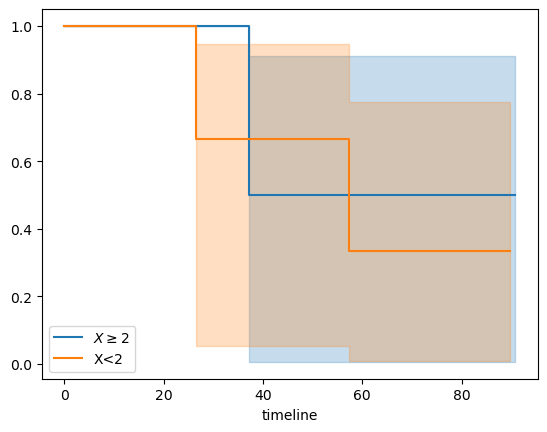

In [5]:
for group, group_df in df.groupby('X<2'):
    km = KaplanMeierFitter()
    if group:
        label = 'X<2'
    else:
        label = r'$X\geq2$'
    km_f = km.fit(group_df['Y'],group_df['d'],label=f'{label}')
    km_f.plot()
    
plt.show()

## (b)
```{admonition}
:class: note
Fit Cox’s proportional hazards model, using the group indicator as a covariate. What is the estimated coefficient? Write a sentence providing the interpretation of this coefficient, in terms of the hazard or the instantaneous probability of the event. Is there evidence that the true coefficient value is non-zero?

In [6]:
cph = CoxPHFitter()
cph.fit(df=df.drop(columns='X'),duration_col='Y',event_col='d')
cph.summary[['coef','exp(coef)','se(coef)','p']]

,coef,exp(coef),se(coef),p
covariate,,,,
X<2,0.340143,1.405149,1.235876,0.783144


If $X<2$, then the hazard is increased by approximately $1.4$ ties.

The $p$ value is significantly above $0.05$, so there is no statistical evidence for the true value being non-zero.

## (c)
```{admonition}
:class: note
Recall from that in the case of a single binary covariate, the log-rank test statistic should be identical to the score statistic for the Cox model. Conduct a log-rank test to determine whether there is a difference between the survival curves for the two groups. How does the $p$-value for the log-rank test statistic compare to the $p$-value for the score statistic for the Cox model from (b)?

In [7]:
cph.log_likelihood_ratio_test()

<lifelines.StatisticalResult: log-likelihood ratio test>
null_distribution = chi squared
  degrees_freedom = 1
        test_name = log-likelihood ratio test

---
 test_statistic    p  -log2(p)
           0.08 0.78      0.36

The $p$ value is identical.